In [56]:
# Install the required packages
# %pip install -r notebook_packages.txt

In [57]:
import pandas as pd

TARGET = "tceq" # target variable to predict orgc or tceq = 'orgc'
file_path = f"D:/tierra/datasets/Mexico_standardized_cfvo_{TARGET}.csv"

df = pd.read_csv(file_path)

print(f"Data shape: {df.shape}")
print(f"Data columns: {df.columns}")

df.head()

Data shape: (5635, 20)
Data columns: Index(['profile_id', 'depth_category', 'date', 'longitude', 'latitude', 'clay',
       'phaq', 'sand', 'silt', 'tceq', 'soil_type', 'slopemean', 'bedrock',
       'cfr', 'temperature', 'precipitation', 'ecoregion_type', 'zone_number',
       'zone_name', 'landcover'],
      dtype='object')


,profile_id,depth_category,date,longitude,latitude,clay,phaq,sand,silt,tceq,soil_type,slopemean,bedrock,cfr,temperature,precipitation,ecoregion_type,zone_number,zone_name,landcover
0,1149115,0_5,2004-5-27,-92.924872,15.375747,11.473293,5.917957,53.411810,35.114897,0.0,FLUVISOL EUTRICO,0.153699,rocas_metamorficas,0.001939,16.675776,147.141876,Terrestre,1.0,Tropical húmeda,10.0
1,1149115,15_30,2004-5-27,-92.924872,15.375747,13.443150,5.854219,33.299825,53.257025,0.0,FLUVISOL EUTRICO,0.153699,rocas_metamorficas,0.011414,16.675776,147.141876,Terrestre,1.0,Tropical húmeda,10.0
2,1149115,5_15,2004-5-27,-92.924872,15.375747,11.914496,5.902915,48.878541,39.206964,0.0,FLUVISOL EUTRICO,0.153699,rocas_metamorficas,0.000931,16.675776,147.141876,Terrestre,1.0,Tropical húmeda,10.0
3,1149116,0_5,2004-11-12,-93.805531,15.933933,10.280596,5.814359,83.221049,6.498355,0.0,REGOSOL EUTRICO,0.153699,rocas_metamorficas,0.001939,14.863654,85.933456,Terrestre,7.0,Inundable o Transición tierra-mar,17.0
4,1149116,15_30,2004-11-12,-93.805531,15.933933,8.312555,6.448620,88.852404,2.835040,0.0,REGOSOL EUTRICO,0.153699,rocas_metamorficas,0.011414,14.863654,85.933456,Terrestre,7.0,Inundable o Transición tierra-mar,17.0


In [58]:
UNITS = "(t/ha)"
COUNTRY = "Mexico"
NUMERIC_FEATURES = ['clay','elcosp','phaq','sand','silt','slopemean','cfr','temperature','precipitation']
CATEGORICAL_FEATURES = ['depth_category','soil_type','bedrock','zone_number','landcover']

# update the list based on columns that exist in the dataframe
NUMERIC_FEATURES = [col for col in NUMERIC_FEATURES if col in df.columns]
print(f"Numeric features: {NUMERIC_FEATURES}")

CATEGORICAL_FEATURES = [col for col in CATEGORICAL_FEATURES if col in df.columns]
print(f"Categorical features: {CATEGORICAL_FEATURES}")

# save plots to a directory
import os
OUTPUT_DIR = f"D:/tierra/outputs/plots/{COUNTRY}-{TARGET}-{UNITS.replace('(','').replace(')','').replace('/','')}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Numeric features: ['clay', 'phaq', 'sand', 'silt', 'slopemean', 'cfr', 'temperature', 'precipitation']
Categorical features: ['depth_category', 'soil_type', 'bedrock', 'zone_number', 'landcover']


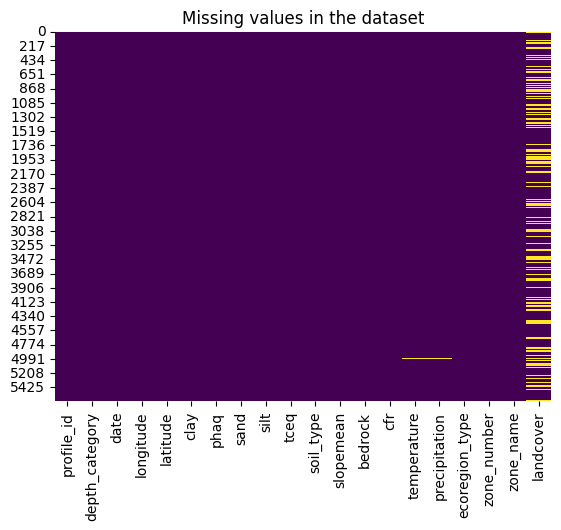

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_missing_values(df):
    # sns plot missing values
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title("Missing values in the dataset")
    # save the plot
    plt.savefig(f"{OUTPUT_DIR}/missing_values.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_missing_values(df)

In [60]:
def preprocess_zone(df):
    # set zone_number as categorical
    df['zone_number'] = df['zone_number'].astype('category').copy()

    # update zone number romans to numeric
    df['zone_number'] = df['zone_number'].cat.rename_categories({'VII': 7, 'VI': 6})

    return df

def preprocess_data(df, target):
    # drop unnecessary columns if exists
    drop_columns = ['country_name', 'region', 'continent', 'ecoregion_type', 'zone_name']
    df.drop(columns=drop_columns, inplace=True, errors='ignore')
    
    # drop missing values in target column
    df.dropna(subset=[target], inplace=True)
    
    # threshold of missing values
    threshold = 0.7 * len(df)
    # drop columns with more than 70% missing values
    cols_to_drop = [col for col in df.columns if df[col].isna().sum() > threshold and col != target]
    df.drop(columns=cols_to_drop, inplace=True)

    print(f"Data shape after dropping columns: {df.shape}")
    print(f"Data columns after dropping columns: {df.columns}")

    # drop duplicates
    df.drop_duplicates(inplace=True)

    # drop any rows with missing values
    df.dropna(inplace=True)

    df = preprocess_zone(df)

    # reset index
    df.reset_index(drop=True, inplace=True)

    return df

In [61]:
df = preprocess_data(df, TARGET)

df.head()

Data shape after dropping columns: (5635, 18)
Data columns after dropping columns: Index(['profile_id', 'depth_category', 'date', 'longitude', 'latitude', 'clay',
       'phaq', 'sand', 'silt', 'tceq', 'soil_type', 'slopemean', 'bedrock',
       'cfr', 'temperature', 'precipitation', 'zone_number', 'landcover'],
      dtype='object')


,profile_id,depth_category,date,longitude,latitude,clay,phaq,sand,silt,tceq,soil_type,slopemean,bedrock,cfr,temperature,precipitation,zone_number,landcover
0,1149115,0_5,2004-5-27,-92.924872,15.375747,11.473293,5.917957,53.411810,35.114897,0.0,FLUVISOL EUTRICO,0.153699,rocas_metamorficas,0.001939,16.675776,147.141876,1.0,10.0
1,1149115,15_30,2004-5-27,-92.924872,15.375747,13.443150,5.854219,33.299825,53.257025,0.0,FLUVISOL EUTRICO,0.153699,rocas_metamorficas,0.011414,16.675776,147.141876,1.0,10.0
2,1149115,5_15,2004-5-27,-92.924872,15.375747,11.914496,5.902915,48.878541,39.206964,0.0,FLUVISOL EUTRICO,0.153699,rocas_metamorficas,0.000931,16.675776,147.141876,1.0,10.0
3,1149116,0_5,2004-11-12,-93.805531,15.933933,10.280596,5.814359,83.221049,6.498355,0.0,REGOSOL EUTRICO,0.153699,rocas_metamorficas,0.001939,14.863654,85.933456,7.0,17.0
4,1149116,15_30,2004-11-12,-93.805531,15.933933,8.312555,6.448620,88.852404,2.835040,0.0,REGOSOL EUTRICO,0.153699,rocas_metamorficas,0.011414,14.863654,85.933456,7.0,17.0


# Calculate stocks

In [62]:
import numpy as np

def calculate_stocks(df, target):
    # Constants
    DEPTH = 30  # cm
    
    # Create a copy to avoid modifying the original dataframe
    df = df.copy()
    
    # Calculate bulk density using Drew (1973) pedotransfer function
    # First convert organic carbon to organic matter (OM = SOC * 1.724)
    if 'orgc' in df.columns:
        om = df['orgc'] * 1.724
        # Drew (1973) equation: BD = 1.62 - 0.06 * OM
        bulk_density = 1.62 - 0.06 * (om/10)  # divide by 10 to convert g/kg to %
    else:
        # Use average bulk density if organic carbon data is not available
        bulk_density = 1.3
    
    # Calculate the correction factor for rock fragments (cfr)
    # cfr is in percentage, divide by 100 to get fraction
    rock_correction = 1 - (df['cfr'] / 100)
    
    # Calculate stocks in tons/ha
    # Stock = concentration * bulk_density * depth * (1 - rock_fraction) * 0.1
    # 0.1 is the conversion factor from g/kg to tons/ha
    stocks = df[target] * bulk_density * DEPTH * rock_correction * 0.1
    
    # Add calculated columns to dataframe
    # df['bulk_density'] = bulk_density
    df[f'{target}_stock'] = stocks
    
    return df

df = calculate_stocks(df, TARGET)
df.head()

,profile_id,depth_category,date,longitude,latitude,clay,phaq,sand,silt,tceq,soil_type,slopemean,bedrock,cfr,temperature,precipitation,zone_number,landcover,tceq_stock
0,1149115,0_5,2004-5-27,-92.924872,15.375747,11.473293,5.917957,53.411810,35.114897,0.0,FLUVISOL EUTRICO,0.153699,rocas_metamorficas,0.001939,16.675776,147.141876,1.0,10.0,0.0
1,1149115,15_30,2004-5-27,-92.924872,15.375747,13.443150,5.854219,33.299825,53.257025,0.0,FLUVISOL EUTRICO,0.153699,rocas_metamorficas,0.011414,16.675776,147.141876,1.0,10.0,0.0
2,1149115,5_15,2004-5-27,-92.924872,15.375747,11.914496,5.902915,48.878541,39.206964,0.0,FLUVISOL EUTRICO,0.153699,rocas_metamorficas,0.000931,16.675776,147.141876,1.0,10.0,0.0
3,1149116,0_5,2004-11-12,-93.805531,15.933933,10.280596,5.814359,83.221049,6.498355,0.0,REGOSOL EUTRICO,0.153699,rocas_metamorficas,0.001939,14.863654,85.933456,7.0,17.0,0.0
4,1149116,15_30,2004-11-12,-93.805531,15.933933,8.312555,6.448620,88.852404,2.835040,0.0,REGOSOL EUTRICO,0.153699,rocas_metamorficas,0.011414,14.863654,85.933456,7.0,17.0,0.0


In [63]:
# drop original target column
df.drop(columns=[TARGET], inplace=True, errors='ignore')

# assign target column to stocks
TARGET = f'{TARGET}_stock'
print(f"Target variable: {TARGET}")

df.head()

Target variable: tceq_stock


,profile_id,depth_category,date,longitude,latitude,clay,phaq,sand,silt,soil_type,slopemean,bedrock,cfr,temperature,precipitation,zone_number,landcover,tceq_stock
0,1149115,0_5,2004-5-27,-92.924872,15.375747,11.473293,5.917957,53.411810,35.114897,FLUVISOL EUTRICO,0.153699,rocas_metamorficas,0.001939,16.675776,147.141876,1.0,10.0,0.0
1,1149115,15_30,2004-5-27,-92.924872,15.375747,13.443150,5.854219,33.299825,53.257025,FLUVISOL EUTRICO,0.153699,rocas_metamorficas,0.011414,16.675776,147.141876,1.0,10.0,0.0
2,1149115,5_15,2004-5-27,-92.924872,15.375747,11.914496,5.902915,48.878541,39.206964,FLUVISOL EUTRICO,0.153699,rocas_metamorficas,0.000931,16.675776,147.141876,1.0,10.0,0.0
3,1149116,0_5,2004-11-12,-93.805531,15.933933,10.280596,5.814359,83.221049,6.498355,REGOSOL EUTRICO,0.153699,rocas_metamorficas,0.001939,14.863654,85.933456,7.0,17.0,0.0
4,1149116,15_30,2004-11-12,-93.805531,15.933933,8.312555,6.448620,88.852404,2.835040,REGOSOL EUTRICO,0.153699,rocas_metamorficas,0.011414,14.863654,85.933456,7.0,17.0,0.0


# Split dataset before Training

In [64]:
# split the data into train and test sets to avoid data leakage
from sklearn.model_selection import train_test_split

# split the data into train and test sets
X = df.drop(columns=[TARGET])
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# save the train and test sets to csv files
X_train.to_csv(f"{OUTPUT_DIR}/X_train.csv", index=False)
X_test.to_csv(f"{OUTPUT_DIR}/X_test.csv", index=False)
y_train.to_csv(f"{OUTPUT_DIR}/y_train.csv", index=False)
y_test.to_csv(f"{OUTPUT_DIR}/y_test.csv", index=False)

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# create a column transformer to preprocess the data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUMERIC_FEATURES),
        ('cat', categorical_transformer, CATEGORICAL_FEATURES)
    ]
)

def train_model(regressor_model, preprocessor, regressor_name):
    # create a pipeline to train the model
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', regressor_model)
    ])

    # fit the model
    model.fit(X_train, y_train)

    # make predictions
    y_pred = model.predict(X_test)

    metrics(regressor_name, y_test, y_pred, True)

    return model, y_test, y_pred

def metrics(regressor_name, y_test, y_pred, print_metrics=False):
    # evaluate the model
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)

    if print_metrics:
        print("-" * 30)
        print(f"Model: {regressor_name} {TARGET} {UNITS} {COUNTRY}")
        print(f"Mean squared error (MSE): {mse:.4f}")
        print(f"Root mean squared error (RMSE): {rmse:.4f}")
        print(f"Mean absolute error (MAE): {mae:.4f}")
        print(f"R2: {r2:.4f}")
        print("-" * 30)

    return mae, mse, r2, rmse

def plot_feature_importance(regressor_name, model):
    # Check if model has feature_importances_ attribute
    if hasattr(model.named_steps['regressor'], 'feature_importances_'):
        # plot the feature importances
        importances = model.named_steps['regressor'].feature_importances_
        feature_names = (NUMERIC_FEATURES + 
                        model.named_steps['preprocessor']
                        .transformers_[1][1]
                        .named_steps['onehot']
                        .get_feature_names_out(CATEGORICAL_FEATURES).tolist())
        indices = np.argsort(importances)[::-1]

        plt.figure(figsize=(10, 6))
        plt.title(f"Feature importances for {regressor_name} {TARGET} {UNITS} {COUNTRY}")
        plt.bar(range(len(importances)), importances[indices], align="center")

        plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
        plt.xlim([-1, len(importances)])
        plt.tight_layout()
        # save the plot
        plot_name = f"{regressor_name}_feature_importance.png"
        plt.savefig(os.path.join(OUTPUT_DIR, plot_name))
        print(f"Feature importance plot saved to {OUTPUT_DIR}")
        plt.show()

    else:
        print(f"Feature importance plot not available for {regressor_name}")

def plot_regression_line(regressor_name, y_test, y_pred, plot_residuals=False):
    
    mae, mse, r2, rmse = metrics(regressor_name, y_test, y_pred, False)

    # plot the predictions vs actual values
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    plt.xlabel("Actual values")
    plt.ylabel("Predicted values")
    plt.title(f"Predictions vs Actual values for {regressor_name} {TARGET} {UNITS} {COUNTRY} \nMSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    plt.tight_layout()
    # save the plot
    plot_name = f"{regressor_name}_predicted_vs_actual.png"
    plt.savefig(os.path.join(OUTPUT_DIR, plot_name))
    print(f"Predicted vs Actual plot saved to {OUTPUT_DIR}")
    plt.show()

    if plot_residuals:
        # plot the residuals
        plt.figure(figsize=(10, 6))
        plt.scatter(y_pred, y_pred - y_test, alpha=0.5)
        plt.axhline(0, color='k', lw=2)
        plt.xlabel("Predicted values")
        plt.ylabel("Residuals")
        plt.title(f"Residuals vs Predicted values for {regressor_name} {TARGET} {UNITS} {COUNTRY}")
        plt.tight_layout()
        plot_name = f"{regressor_name}_residuals.png"
        plt.savefig(os.path.join(OUTPUT_DIR, plot_name))
        print(f"Residuals plot saved to {OUTPUT_DIR}")
        plt.show()

------------------------------
Model: Baseline model tceq_stock (t/ha) Mexico
Mean squared error (MSE): 389997.1610
Root mean squared error (RMSE): 624.4975
Mean absolute error (MAE): 432.1330
R2: -0.0001
------------------------------
Predicted vs Actual plot saved to D:/tierra/outputs/plots/Mexico-tceq-tha


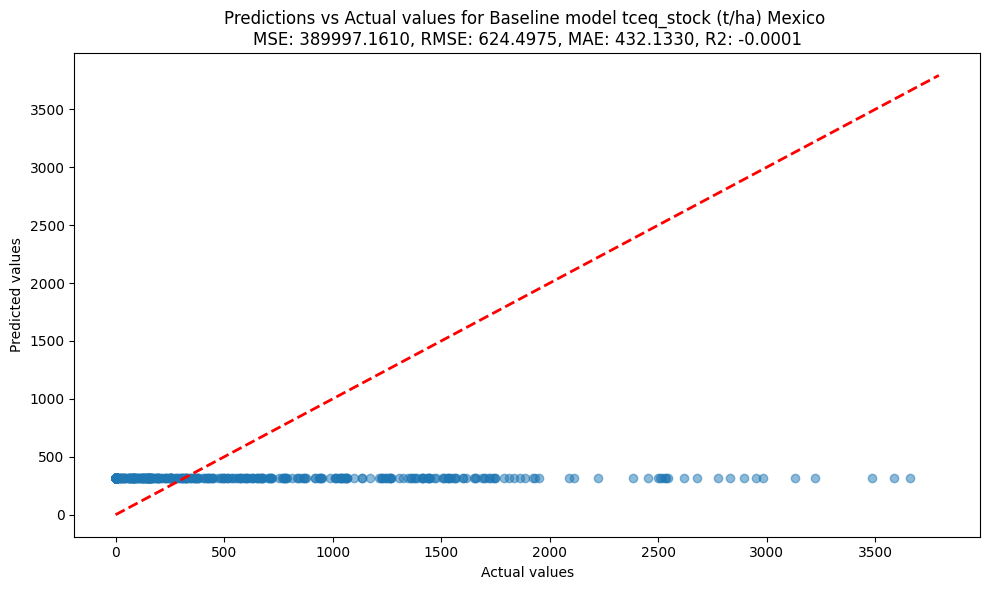

------------------------------
Model: Random Forest tceq_stock (t/ha) Mexico
Mean squared error (MSE): 71568.7861
Root mean squared error (RMSE): 267.5234
Mean absolute error (MAE): 109.8491
R2: 0.8165
------------------------------
Predicted vs Actual plot saved to D:/tierra/outputs/plots/Mexico-tceq-tha


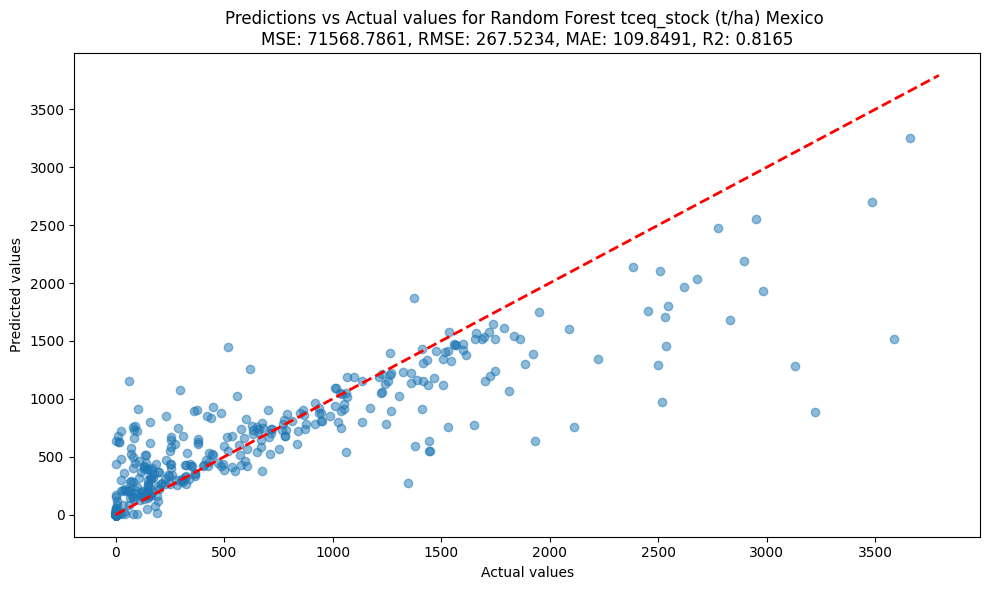

Feature importance plot saved to D:/tierra/outputs/plots/Mexico-tceq-tha


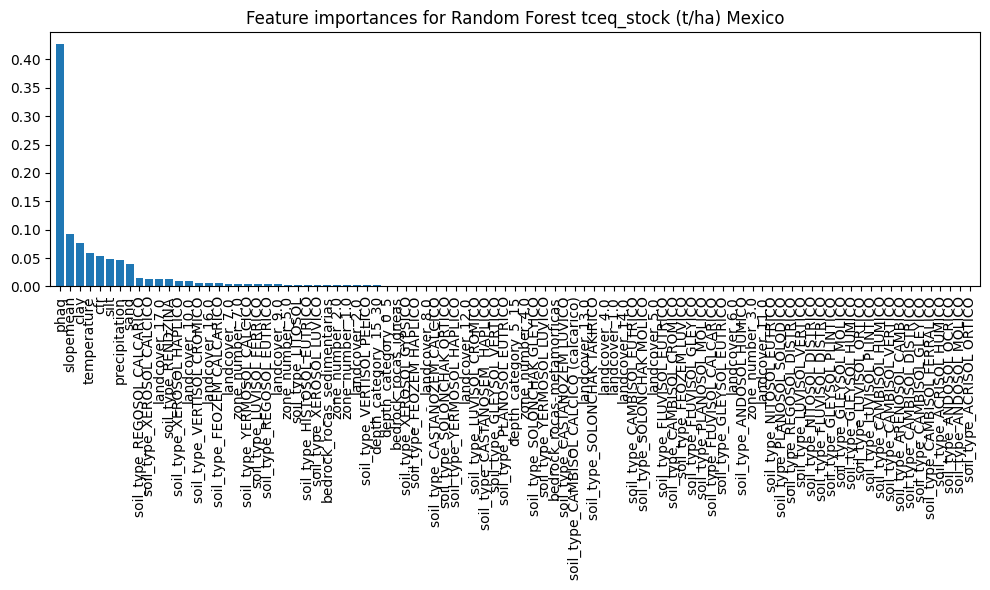

Model saved to D:/tierra/outputs/plots/Mexico-tceq-tha\Random Forest.joblib
------------------------------
Model: Gradient Boosting tceq_stock (t/ha) Mexico
Mean squared error (MSE): 138827.9237
Root mean squared error (RMSE): 372.5962
Mean absolute error (MAE): 194.8845
R2: 0.6440
------------------------------
Predicted vs Actual plot saved to D:/tierra/outputs/plots/Mexico-tceq-tha


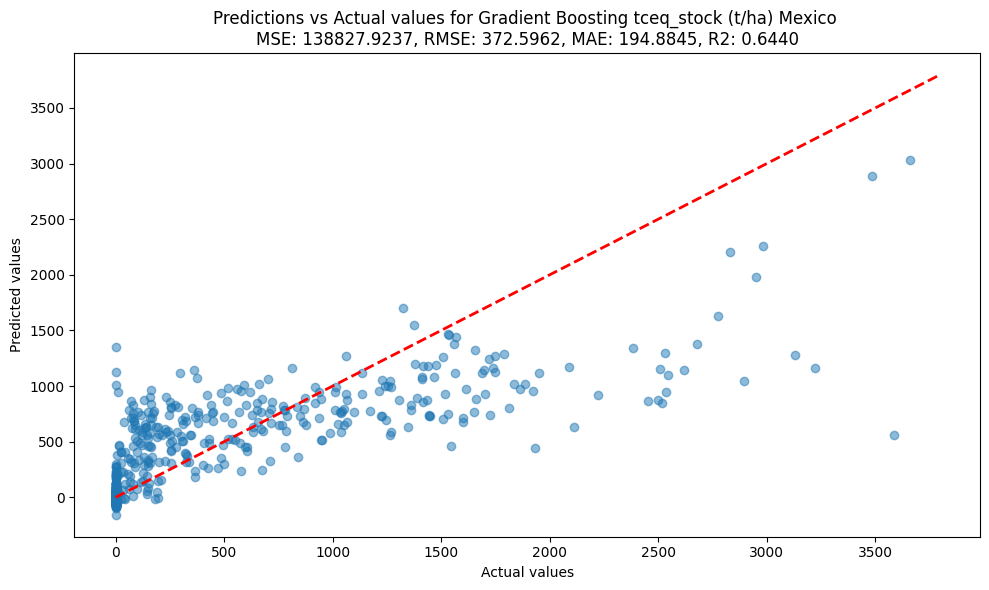

Feature importance plot saved to D:/tierra/outputs/plots/Mexico-tceq-tha


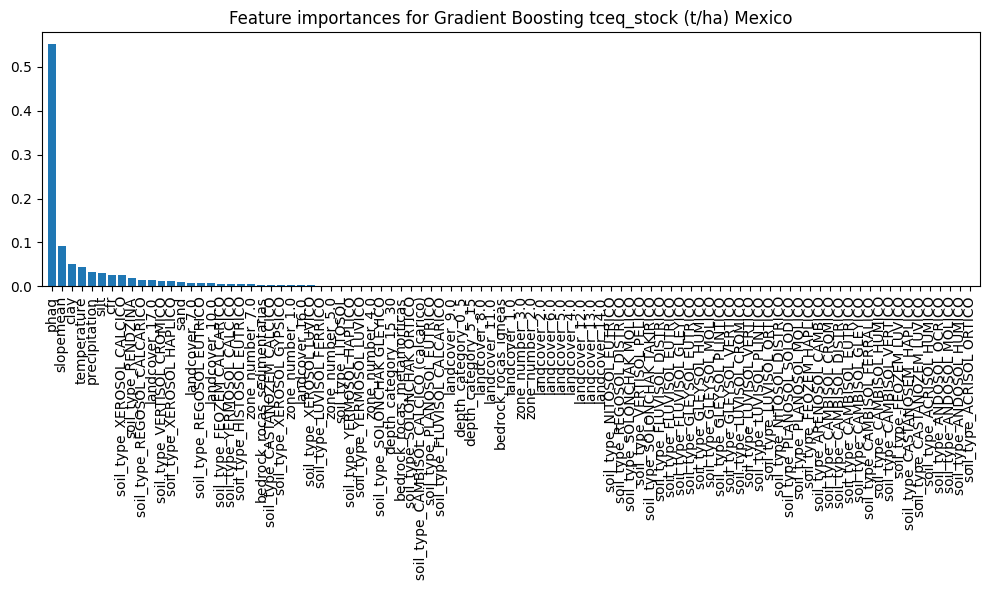

Model saved to D:/tierra/outputs/plots/Mexico-tceq-tha\Gradient Boosting.joblib
------------------------------
Model: Linear Regression tceq_stock (t/ha) Mexico
Mean squared error (MSE): 217514.5732
Root mean squared error (RMSE): 466.3846
Mean absolute error (MAE): 296.0644
R2: 0.4422
------------------------------
Predicted vs Actual plot saved to D:/tierra/outputs/plots/Mexico-tceq-tha


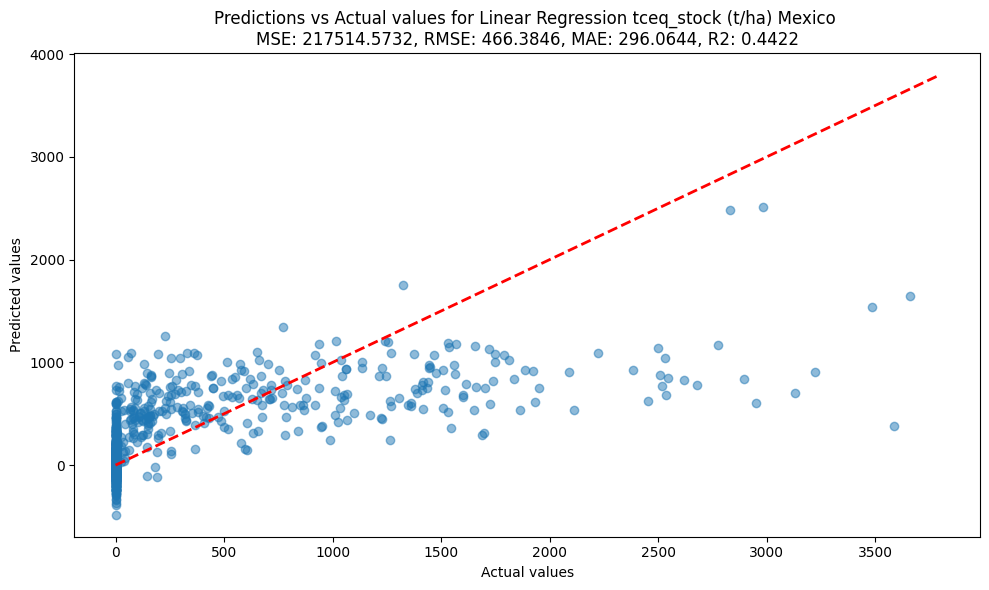

Feature importance plot not available for Linear Regression
Model saved to D:/tierra/outputs/plots/Mexico-tceq-tha\Linear Regression.joblib
------------------------------
Model: MLP Regressor tceq_stock (t/ha) Mexico
Mean squared error (MSE): 482613.1122
Root mean squared error (RMSE): 694.7036
Mean absolute error (MAE): 315.5417
R2: -0.2376
------------------------------
Predicted vs Actual plot saved to D:/tierra/outputs/plots/Mexico-tceq-tha


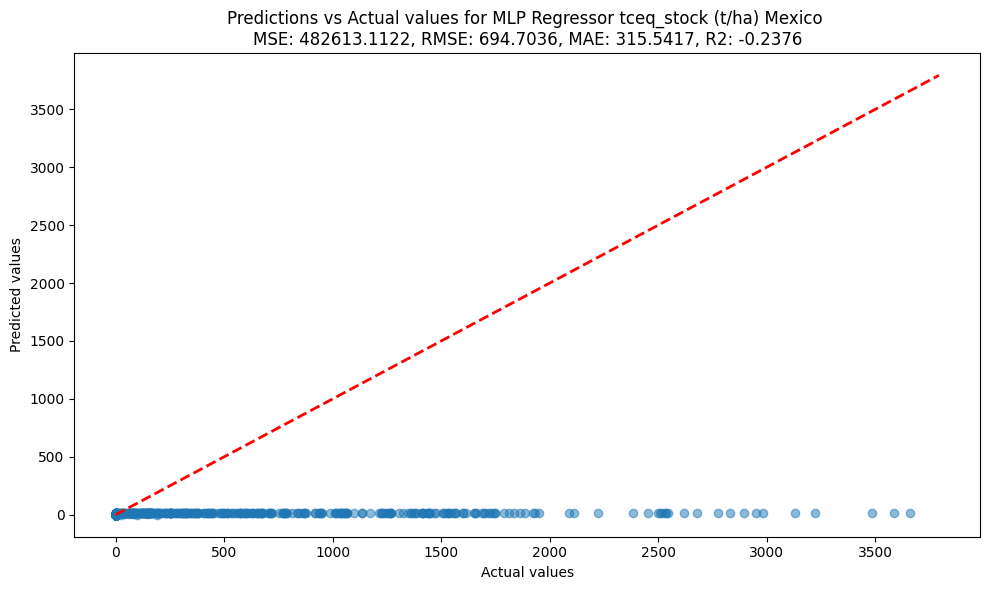

Feature importance plot not available for MLP Regressor
Model saved to D:/tierra/outputs/plots/Mexico-tceq-tha\MLP Regressor.joblib
------------------------------
Model: SVR tceq_stock (t/ha) Mexico
Mean squared error (MSE): 449836.6928
Root mean squared error (RMSE): 670.6987
Mean absolute error (MAE): 301.0523
R2: -0.1535
------------------------------
Predicted vs Actual plot saved to D:/tierra/outputs/plots/Mexico-tceq-tha


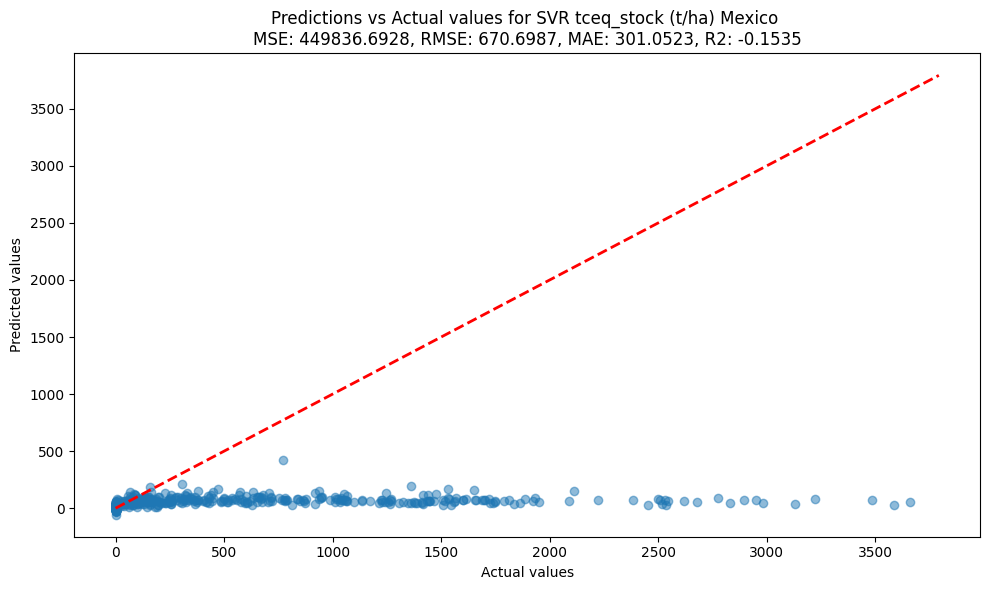

Feature importance plot not available for SVR
Model saved to D:/tierra/outputs/plots/Mexico-tceq-tha\SVR.joblib


In [66]:
# models to train
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
import joblib

# define list of models to train
models = [
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ("Linear Regression", LinearRegression()),
    ("MLP Regressor", MLPRegressor(hidden_layer_sizes=(2,2), max_iter=1000, random_state=42)),
    ("SVR", SVR(kernel='poly'))
]

# baseline mean model
y_pred = [y_train.mean()] * len(y_test)
metrics(f"Baseline model", y_test, y_pred, True)
plot_regression_line(f"Baseline model", y_test, y_pred)

# iterate over the models and train them
for regressor_name, regressor_model in models:
    model, y_test, y_pred = train_model(regressor_model, preprocessor, regressor_name)
    plot_regression_line(regressor_name, y_test, y_pred)
    plot_feature_importance(regressor_name, model)

    # save the model to a file
    model_file = os.path.join(OUTPUT_DIR, f"{regressor_name}.joblib")
    joblib.dump(model, model_file)
    print(f"Model saved to {model_file}")